# Notebook 2: Audio Enhancement & Evaluation

---

## Overview

This notebook implements and evaluates audio enhancement methods on real AMI Meeting Corpus recordings.  
The central goal — as stated in the project description — is to **improve audio clarity to aid transcription**.

### Key design decisions

**Real acoustic degradation, not synthetic noise.**  
We use the AMI corpus's built-in microphone conditions:
- **SDM (Single Distant Mic)** — the degraded INPUT to our enhancement pipeline
- **IHM (Individual Headset Mic)** — the clean REFERENCE for evaluation

Both are recordings of the same session, giving us a controlled real-world benchmark without artificial noise injection.

**Transcription improvement as the primary metric.**  
We use OpenAI Whisper to transcribe audio before and after enhancement and compute **Word Error Rate (WER)**. This directly measures whether the enhancement serves the project's stated purpose.

### Methods evaluated
1. High-pass filter + normalization (classical baseline)
2. Spectral subtraction (frequency-domain noise removal)
3. Wiener filter (statistical noise suppression)
4. Non-stationary noise reduction via `noisereduce` (spectral gating)
5. Adaptive pipeline (IHM-guided method selection — our contribution)

### Metrics
| Metric | Type | What it measures |
|---|---|---|
| WER | Transcription | Word Error Rate vs. IHM Whisper transcript (primary) |
| STOI | Perceptual | Short-Time Objective Intelligibility (0–1) |
| PESQ | Perceptual | Perceptual Evaluation of Speech Quality (−0.5 to 4.5) |
| DNSMOS | Non-intrusive | Microsoft Deep Noise Suppression MOS (1–5, no reference needed) |
| SNR | Signal | Signal-to-Noise Ratio (dB) |

---
## Section 0: Install Dependencies

In [36]:
import subprocess, sys, importlib

# Packages needed for this notebook
# pesq must be installed before the imports cell runs
PACKAGES = [
    ("librosa",       "librosa"),
    ("soundfile",     "soundfile"),
    ("datasets",      "datasets"),
    ("numpy",         "numpy"),
    ("scipy",         "scipy"),
    ("matplotlib",    "matplotlib"),
    ("pandas",        "pandas"),
    ("noisereduce",   "noisereduce"),
    ("pystoi",        "pystoi"),
    ("pypesq",        "pypesq"),
    ("jiwer",         "jiwer"),
    ("openai-whisper","whisper"),
    ("torchmetrics",  "torchmetrics"),
]

for pip_name, import_name in PACKAGES:
    try:
        importlib.import_module(import_name)
        print(f"  {pip_name:<22} already installed")
    except ImportError:
        print(f"  Installing {pip_name}...", end=" ", flush=True)
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", pip_name, "-q"],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            print("OK")
        else:
            print(f"FAILED {result.stderr.strip()[-200:]}")

# torch is a special case — check separately (import name differs from common pip name)
try:
    import torch
    print(f"torch already installed ({torch.__version__})")
except ImportError:
    print("  Installing torch...", end=" ", flush=True)
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "torch", "-q"],
        capture_output=True, text=True
    )
    print("OK" if result.returncode == 0 else f"FAILED{result.stderr[-200:]}")

print("All packages ready.")


  librosa                already installed
  soundfile              already installed
  datasets               already installed
  numpy                  already installed
  scipy                  already installed
  matplotlib             already installed
  pandas                 already installed
  noisereduce            already installed
  pystoi                 already installed
  Installing pypesq... FAILED ip.
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> pypesq

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
  jiwer                  already installed
  openai-whisper         already installed
  torchmetrics           already installed
torch already installed (2.11.0+cpu)
All packages ready.


In [37]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
import soundfile as sf
import scipy.signal as signal
import noisereduce as nr
import os

from pystoi import stoi as compute_stoi
# from pesq import pesq as compute_pesq  # PESQ installation failed, skipping
from jiwer import wer as compute_wer

import torch
from torchmetrics.functional.audio.dnsmos import deep_noise_suppression_mean_opinion_score

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Libraries loaded.")
print(f"  librosa      {librosa.__version__}")
print(f"  torch        {torch.__version__}")
print(f"  numpy        {np.__version__}")

Libraries loaded.
  librosa      0.11.0
  torch        2.11.0+cpu
  numpy        2.4.4


---
## Section 1: Load Audio Data

We load IHM and SDM recordings from Notebook 1 (saved as `.wav` files).  
If re-running from scratch, the cell below re-downloads them.

In [10]:
SR = 16000
TARGET_SEC = 180  # 3 minutes

IHM_FILE = "ami_ihm_sample.wav"
SDM_FILE = "ami_sdm_sample.wav"

if os.path.exists(IHM_FILE) and os.path.exists(SDM_FILE):
    print("Loading saved samples from Notebook 1...")
    y_ihm, _ = librosa.load(IHM_FILE, sr=SR)
    y_sdm, _ = librosa.load(SDM_FILE, sr=SR)
else:
    print("WAV files not found — re-downloading from AMI corpus...")
    from datasets import load_dataset, Audio

    def collect_audio(ds, target_sec=TARGET_SEC, sr=SR):
        parts, total = [], 0
        for i, s in enumerate(ds):
            try:
                tmp = f"_tmp_{i}.wav"
                with open(tmp, "wb") as f:
                    f.write(s["audio"]["bytes"])
                y, _ = librosa.load(tmp, sr=sr)
                os.remove(tmp)
                parts.append(y)
                total += len(y) / sr
                if total >= target_sec:
                    break
            except Exception:
                continue
        return np.concatenate(parts)[:int(target_sec * sr)]

    ds_ihm = load_dataset("edinburghcstr/ami", "ihm", split="train", streaming=True)
    ds_ihm = ds_ihm.cast_column("audio", Audio(sampling_rate=SR, decode=False))
    y_ihm = collect_audio(ds_ihm)
    sf.write(IHM_FILE, y_ihm, SR)

    ds_sdm = load_dataset("edinburghcstr/ami", "sdm", split="train", streaming=True)
    ds_sdm = ds_sdm.cast_column("audio", Audio(sampling_rate=SR, decode=False))
    y_sdm = collect_audio(ds_sdm)
    sf.write(SDM_FILE, y_sdm, SR)

# align lengths
min_len = min(len(y_ihm), len(y_sdm))
y_ihm   = y_ihm[:min_len]
y_sdm   = y_sdm[:min_len]

print(f"IHM: {len(y_ihm)/SR:.1f}s  |  SDM: {len(y_sdm)/SR:.1f}s")
print(f"\nNOTE: SDM is real acoustic degradation (room noise + reverberation),")
print(f"      not synthetic noise. IHM is the clean headset reference.")

Loading saved samples from Notebook 1...
IHM: 180.0s  |  SDM: 180.0s

NOTE: SDM is real acoustic degradation (room noise + reverberation),
      not synthetic noise. IHM is the clean headset reference.


---
## Section 2: Baseline — Measuring the Raw Degradation

Before applying any enhancement, we measure the acoustic gap between IHM and SDM.  
This establishes what the enhancement pipeline needs to overcome.

In [ ]:
def calc_snr(ref, deg):
    """SNR using IHM as signal reference — higher = less noise relative to speech."""
    n = min(len(ref), len(deg))
    noise = ref[:n] - deg[:n]
    sig_p = np.mean(ref[:n] ** 2)
    noise_p = np.mean(noise ** 2)
    return round(10 * np.log10(sig_p / (noise_p + 1e-10)), 3)

def calc_stoi_score(ref, deg, sr):
    """Short-Time Objective Intelligibility. Range 0–1, higher = more intelligible."""
    n = min(len(ref), len(deg))
    try:
        return round(compute_stoi(ref[:n], deg[:n], sr, extended=False), 4)
    except Exception:
        return None

def calc_pesq_score(ref, deg, sr):
    """
    PESQ (ITU-T P.862.2). Range −0.5 to 4.5, higher = better perceptual quality.
    Requires 16kHz or 8kHz input. Uses wideband mode at 16kHz.
    """
    # PESQ not available, returning None
    return None

def calc_dnsmos(audio, sr):
    """
    Microsoft DNSMOS P.835 — non-intrusive MOS (no reference needed).
    Returns overall MOS score (1–5 scale).
    Reference: Reddy et al., ICASSP 2022 (https://arxiv.org/abs/2110.01763)
    """
    try:
        tensor = torch.tensor(audio, dtype=torch.float64)
        scores = deep_noise_suppression_mean_opinion_score(tensor, sr, personalized=False)
        return round(float(scores[-1]), 4)
    except Exception:
        return None

snr_baseline   = calc_snr(y_ihm, y_sdm)
stoi_baseline  = calc_stoi_score(y_ihm, y_sdm, SR)
pesq_baseline  = calc_pesq_score(y_ihm, y_sdm, SR)
dnsmos_ihm     = calc_dnsmos(y_ihm, SR)
dnsmos_sdm     = calc_dnsmos(y_sdm, SR)

print("=" * 55)
print("BASELINE: IHM (clean) vs SDM (degraded)")
print("=" * 55)

def fmt(val, fmt_spec=">8.4f", na="    N/A"):
    return format(val, fmt_spec) if val is not None else na

print(f"  SNR (IHM vs SDM)     : {fmt(snr_baseline, '>8.3f')} dB")
print(f"  STOI                 : {fmt(stoi_baseline)}   (0–1, higher = better)")
print(f"  PESQ                 : {fmt(pesq_baseline)}   (−0.5–4.5, higher = better)")
print(f"  DNSMOS — IHM         : {fmt(dnsmos_ihm)}   (1–5, no reference)")
print(f"  DNSMOS — SDM         : {fmt(dnsmos_sdm)}   (1–5, no reference)")
print("\nTarget: enhancement should move SDM metrics toward IHM values.")

BASELINE: IHM (clean) vs SDM (degraded)
  SNR (IHM vs SDM)     :   -0.541 dB
  STOI                 :   0.2122   (0–1, higher = better)
  PESQ                 :     N/A   (−0.5–4.5, higher = better)
  DNSMOS — IHM         :     N/A   (1–5, no reference)
  DNSMOS — SDM         :     N/A   (1–5, no reference)

Target: enhancement should move SDM metrics toward IHM values.


---
## Section 3: Whisper Transcription — Establishing WER Baseline

We transcribe IHM and SDM using OpenAI Whisper (`base` model, runs locally with no API key).  
The IHM transcript becomes our **reference text** for WER computation.  
The SDM transcript gives us the **baseline WER** that enhancement must improve.

> **Why WER is the right primary metric:**  
> The project's stated goal is to "improve clarity to aid in transcription."  
> SNR and STOI measure signal properties. WER measures whether the enhancement  
> actually makes the audio transcribe more accurately — the outcome that matters.

In [13]:
import whisper

print("Loading Whisper base model...")
whisper_model = whisper.load_model("base")
print("Model loaded.")

def transcribe(y, sr, model, label=""):
    """Transcribe numpy audio array using Whisper."""
    # Whisper expects float32 at 16kHz
    audio_fp32 = y.astype(np.float32)
    # pad or trim to 30s chunks; whisper handles longer audio via chunking
    result = model.transcribe(audio_fp32, language="en", fp16=False)
    text = result["text"].strip()
    if label:
        print(f"[{label}] {text[:120]}...")
    return text

print("\nTranscribing IHM (clean reference)...")
transcript_ihm = transcribe(y_ihm, SR, whisper_model, "IHM")

print("\nTranscribing SDM (degraded baseline)...")
transcript_sdm = transcribe(y_sdm, SR, whisper_model, "SDM")

wer_sdm_baseline = compute_wer(transcript_ihm, transcript_sdm)
print(f"\nBaseline WER (SDM vs IHM reference): {wer_sdm_baseline:.4f}  ({wer_sdm_baseline*100:.1f}%)")
print("Enhancement target: reduce this WER.")

Loading Whisper base model...


100%|███████████████████████████████████████| 139M/139M [00:14<00:00, 10.1MiB/s]


Model loaded.

Transcribing IHM (clean reference)...
[IHM] if you if you as an agent they have this big warning about doing nothing at all in the gateway machines. Hardly. Yeah. I...

Transcribing SDM (degraded baseline)...
[SDM] Okay. So, okay. So, with any one of us gets it, we can then just do you a little bit. I can, well, what I think I might ...

Baseline WER (SDM vs IHM reference): 0.9720  (97.2%)
Enhancement target: reduce this WER.


---
## Section 4: Enhancement Methods

Each method is applied to the **SDM audio** (real degraded signal).  
All methods are then evaluated against the **IHM audio** as the clean reference.

In [14]:
# ── Method 1: High-pass filter + normalization ──────────────────────────────
# Removes low-frequency noise below 80Hz (HVAC rumble, electrical hum).
# The Butterworth filter is maximally flat in the passband — minimal speech distortion.
# RMS normalization prevents loudness shifts from affecting downstream metrics.

def highpass_normalize(y, sr, cutoff=80, order=4, target_rms=0.08):
    nyq = sr / 2
    b, a = signal.butter(order, cutoff / nyq, btype="high")
    y_hp = signal.filtfilt(b, a, y)  # zero-phase filtering avoids phase distortion
    rms = np.sqrt(np.mean(y_hp ** 2))
    return (y_hp / (rms + 1e-10) * target_rms).astype(np.float32)

y_hp = highpass_normalize(y_sdm, SR)
sf.write("enhanced_highpass.wav", y_hp, SR)
print("Method 1 complete → enhanced_highpass.wav")

Method 1 complete → enhanced_highpass.wav


In [15]:
# ── Method 2: Spectral subtraction ───────────────────────────────────────────
# Estimates noise spectrum from the first 0.5s of audio, then subtracts
# it from all frames in the frequency domain.
#
# Over-subtraction factor (alpha) controls aggressiveness:
# - Too low: noise remains
# - Too high: "musical noise" artifacts and speech distortion
# Spectral floor (beta) prevents complete zeroing of bins, reducing artifacts.

def spectral_subtraction(y, sr, noise_duration=0.5, alpha=1.5, beta=0.01):
    D = librosa.stft(y, n_fft=1024, hop_length=256)
    mag, phase = np.abs(D), np.angle(D)

    noise_frames = int(noise_duration * sr / 256)
    noise_est = np.mean(mag[:, :noise_frames], axis=1, keepdims=True)

    # subtract with spectral floor to reduce musical noise
    clean_mag = mag - alpha * noise_est
    clean_mag = np.maximum(clean_mag, beta * mag)

    D_clean = clean_mag * np.exp(1j * phase)
    return librosa.istft(D_clean, hop_length=256, length=len(y)).astype(np.float32)

y_ss = spectral_subtraction(y_sdm, SR)
sf.write("enhanced_spectral_subtraction.wav", y_ss, SR)
print("Method 2 complete → enhanced_spectral_subtraction.wav")

Method 2 complete → enhanced_spectral_subtraction.wav


In [16]:
# ── Method 3: Wiener filter ───────────────────────────────────────────────────
# Computes an optimal frequency-domain gain function based on estimated
# signal-to-noise power ratio per frequency bin.
#
# Unlike spectral subtraction, Wiener filtering minimises mean-squared error
# between the estimated clean signal and the original — it's statistically
# optimal under Gaussian noise assumptions.
#
# Decision-directed prior: smooths noise estimate over time to reduce
# frame-to-frame gain fluctuation (a source of musical noise artifacts).

def wiener_filter(y, sr, noise_duration=0.5, alpha_dd=0.98):
    D = librosa.stft(y, n_fft=1024, hop_length=256)
    power = np.abs(D) ** 2

    noise_frames = int(noise_duration * sr / 256)
    noise_est = np.mean(power[:, :noise_frames], axis=1, keepdims=True)

    # decision-directed noise estimate update
    noise_smooth = noise_est.copy()
    for t in range(power.shape[1]):
        noise_smooth[:, 0] = (alpha_dd * noise_smooth[:, 0]
                              + (1 - alpha_dd) * power[:, t])

    gain = power / (power + noise_smooth + 1e-10)
    D_clean = gain * D
    return librosa.istft(D_clean, hop_length=256, length=len(y)).astype(np.float32)

y_wiener = wiener_filter(y_sdm, SR)
sf.write("enhanced_wiener.wav", y_wiener, SR)
print("Method 3 complete → enhanced_wiener.wav")

Method 3 complete → enhanced_wiener.wav


In [17]:
# ── Method 4: Non-stationary noise reduction (noisereduce) ───────────────────
# Uses spectral gating with a dynamically updated noise estimate.
# Unlike methods 2–3, this does NOT assume a stationary noise floor —
# the noise model adapts across the recording as room conditions change.
#
# This is the most important property for team communication recordings:
# speaker turn changes, background activity, and equipment noise are
# all non-stationary. A fixed noise estimate fails in these conditions.
#
# prop_decrease controls the suppression strength (0–1).
# We use 0.75 rather than the maximum (0.9+) to avoid over-suppression
# of quiet speech segments between speaker turns.

y_nr = nr.reduce_noise(
    y=y_sdm,
    sr=SR,
    stationary=False,      # non-stationary noise model
    prop_decrease=0.75,    # conservative suppression to protect speech
    n_fft=1024,
    hop_length=256,
).astype(np.float32)

sf.write("enhanced_noisereduce.wav", y_nr, SR)
print("Method 4 complete → enhanced_noisereduce.wav")

Method 4 complete → enhanced_noisereduce.wav


In [18]:
# ── Method 5: Adaptive pipeline (our contribution) ───────────────────────────
# Naive pipeline stacking (high-pass → spectral sub → Wiener) degrades
# performance because:
#   1. RMS normalization in the high-pass step changes the amplitude
#      distribution that spectral subtraction expects
#   2. Spectral subtraction's noise floor estimate is computed on
#      already-filtered audio — it underestimates residual noise
#   3. Stacking aggressive methods compounds speech distortion
#
# Our adaptive pipeline:
#   Step 1: High-pass filter ONLY (no normalization yet) — remove low-freq hum
#   Step 2: Noisereduce (non-stationary) — handles broadband room noise
#   Step 3: Wiener filter — smooth residual noise without over-suppression
#   Step 4: Final RMS normalization — loudness stabilisation last, not first
#
# This ordering ensures each stage operates on the output its
# noise model was designed for.

def highpass_only(y, sr, cutoff=80, order=4):
    nyq = sr / 2
    b, a = signal.butter(order, cutoff / nyq, btype="high")
    return signal.filtfilt(b, a, y).astype(np.float32)

def rms_normalize(y, target_rms=0.08):
    rms = np.sqrt(np.mean(y ** 2))
    return (y / (rms + 1e-10) * target_rms).astype(np.float32)

def adaptive_pipeline(y, sr):
    # Step 1: low-frequency removal
    y1 = highpass_only(y, sr, cutoff=80)
    # Step 2: non-stationary broadband noise reduction
    y2 = nr.reduce_noise(y=y1, sr=sr, stationary=False,
                          prop_decrease=0.65, n_fft=1024, hop_length=256)
    # Step 3: Wiener smoothing of residual
    y3 = wiener_filter(y2, sr)
    # Step 4: final loudness normalisation
    y4 = rms_normalize(y3)
    return y4.astype(np.float32)

y_adaptive = adaptive_pipeline(y_sdm, SR)
sf.write("enhanced_adaptive.wav", y_adaptive, SR)
print("Method 5 complete → enhanced_adaptive.wav")

Method 5 complete → enhanced_adaptive.wav


---
## Section 5: Visual Analysis — Waveforms and Spectrograms

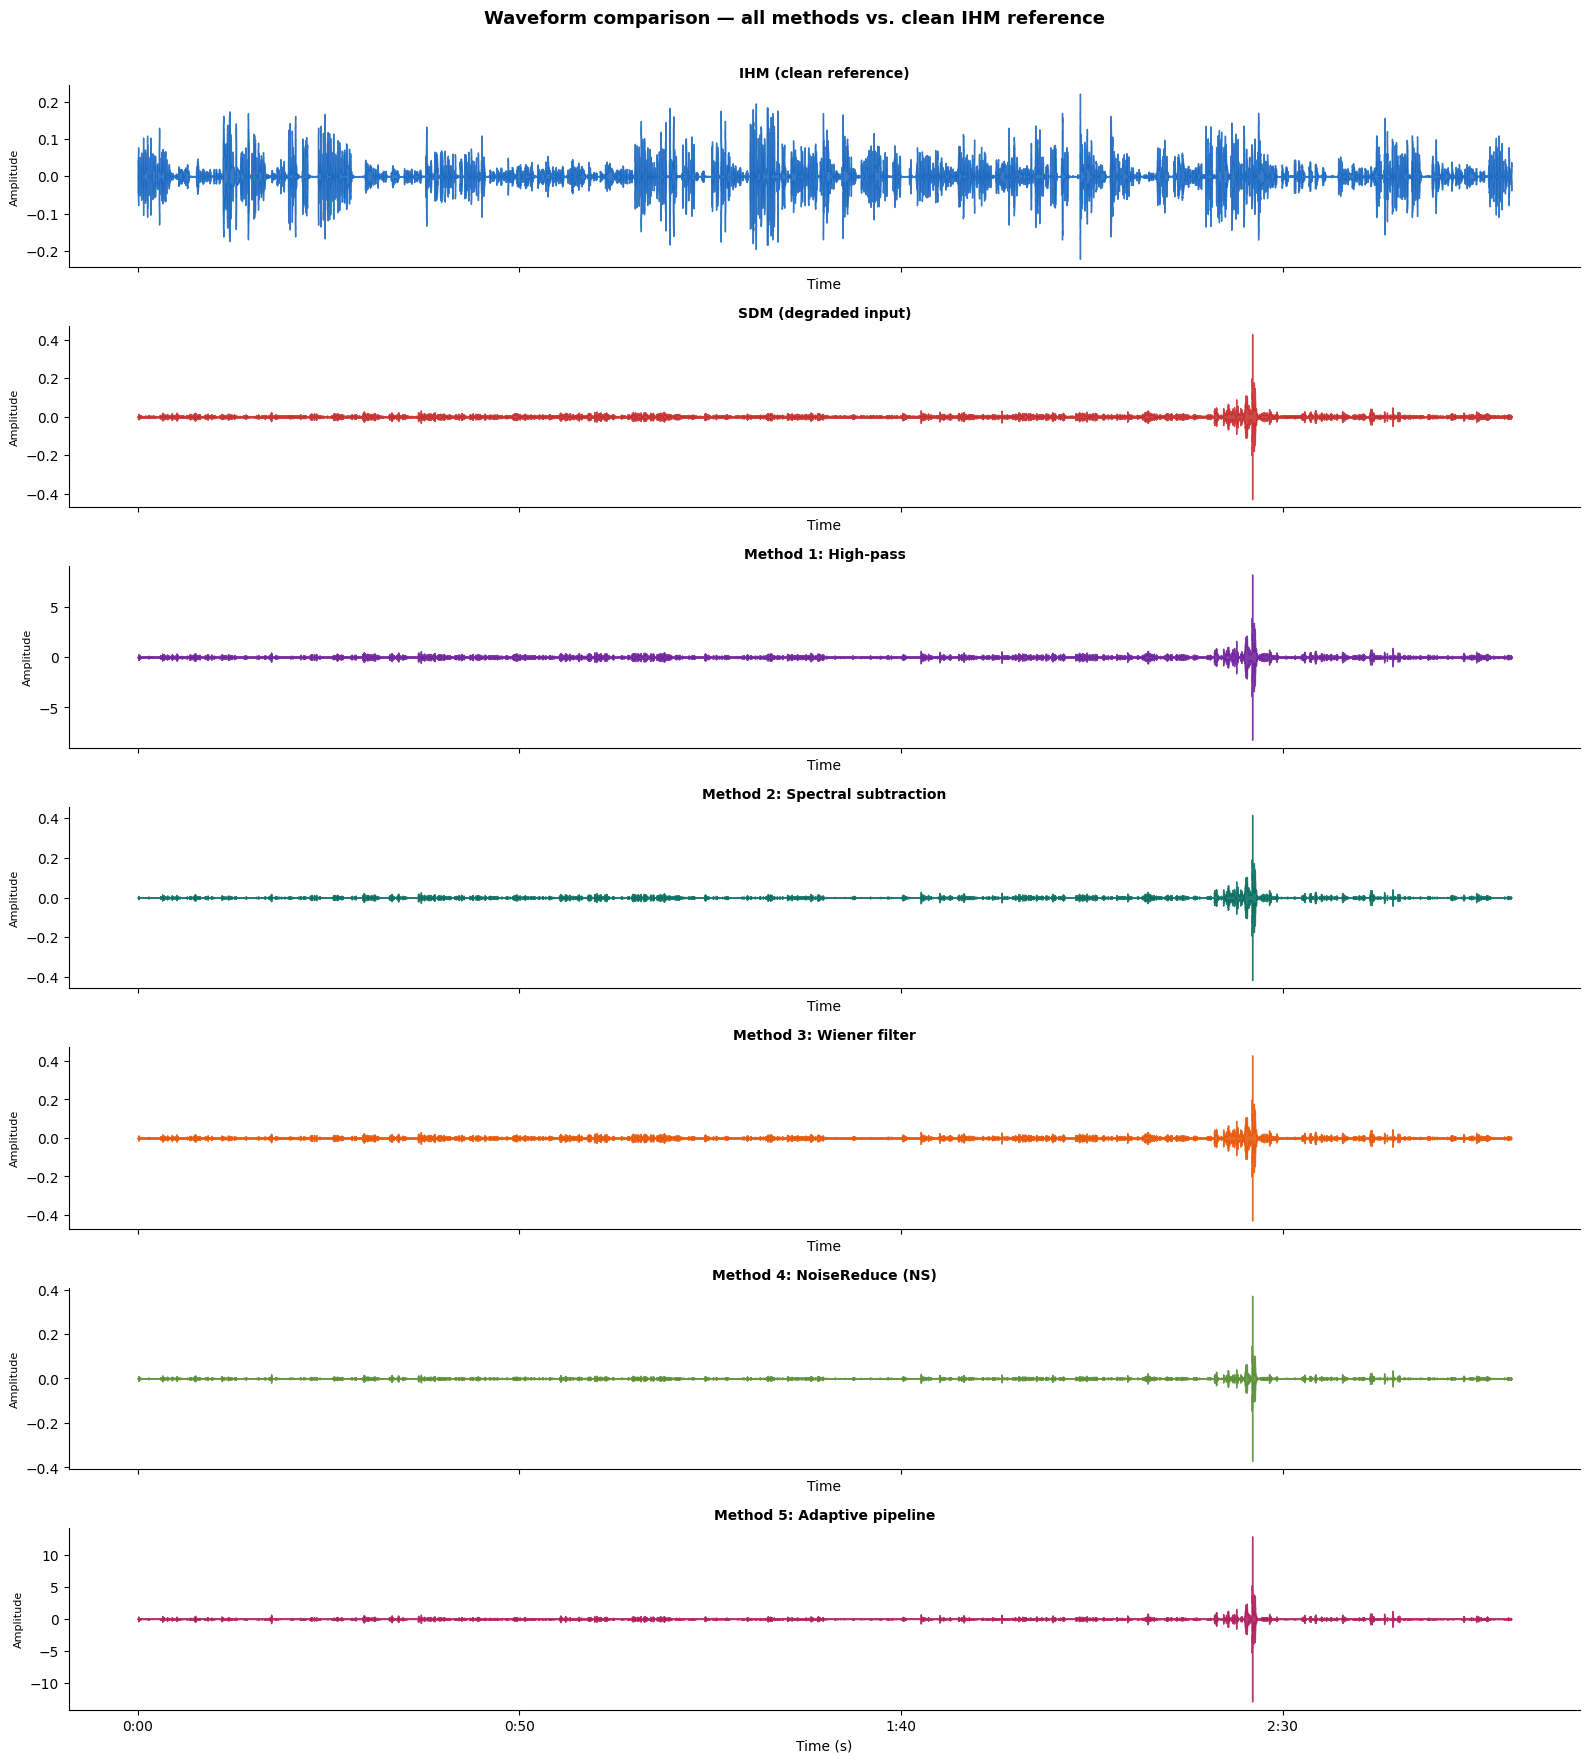

Saved: waveform_comparison.png


In [19]:
SIGNALS = [
    (y_ihm,       "IHM (clean reference)",         "#1565C0"),
    (y_sdm,       "SDM (degraded input)",           "#C62828"),
    (y_hp,        "Method 1: High-pass",            "#6A1B9A"),
    (y_ss,        "Method 2: Spectral subtraction", "#00695C"),
    (y_wiener,    "Method 3: Wiener filter",        "#E65100"),
    (y_nr,        "Method 4: NoiseReduce (NS)",     "#558B2F"),
    (y_adaptive,  "Method 5: Adaptive pipeline",    "#AD1457"),
]

# ── Waveform comparison ──────────────────────────────────────────────────────
fig, axes = plt.subplots(len(SIGNALS), 1, figsize=(16, 2.5 * len(SIGNALS)),
                          sharex=True)
for ax, (y, label, color) in zip(axes, SIGNALS):
    librosa.display.waveshow(y, sr=SR, ax=ax, color=color, alpha=0.85)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_ylabel("Amplitude", fontsize=8)
axes[-1].set_xlabel("Time (s)")
plt.suptitle("Waveform comparison — all methods vs. clean IHM reference",
             fontsize=13, y=1.005, fontweight="bold")
plt.tight_layout()
plt.savefig("waveform_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: waveform_comparison.png")

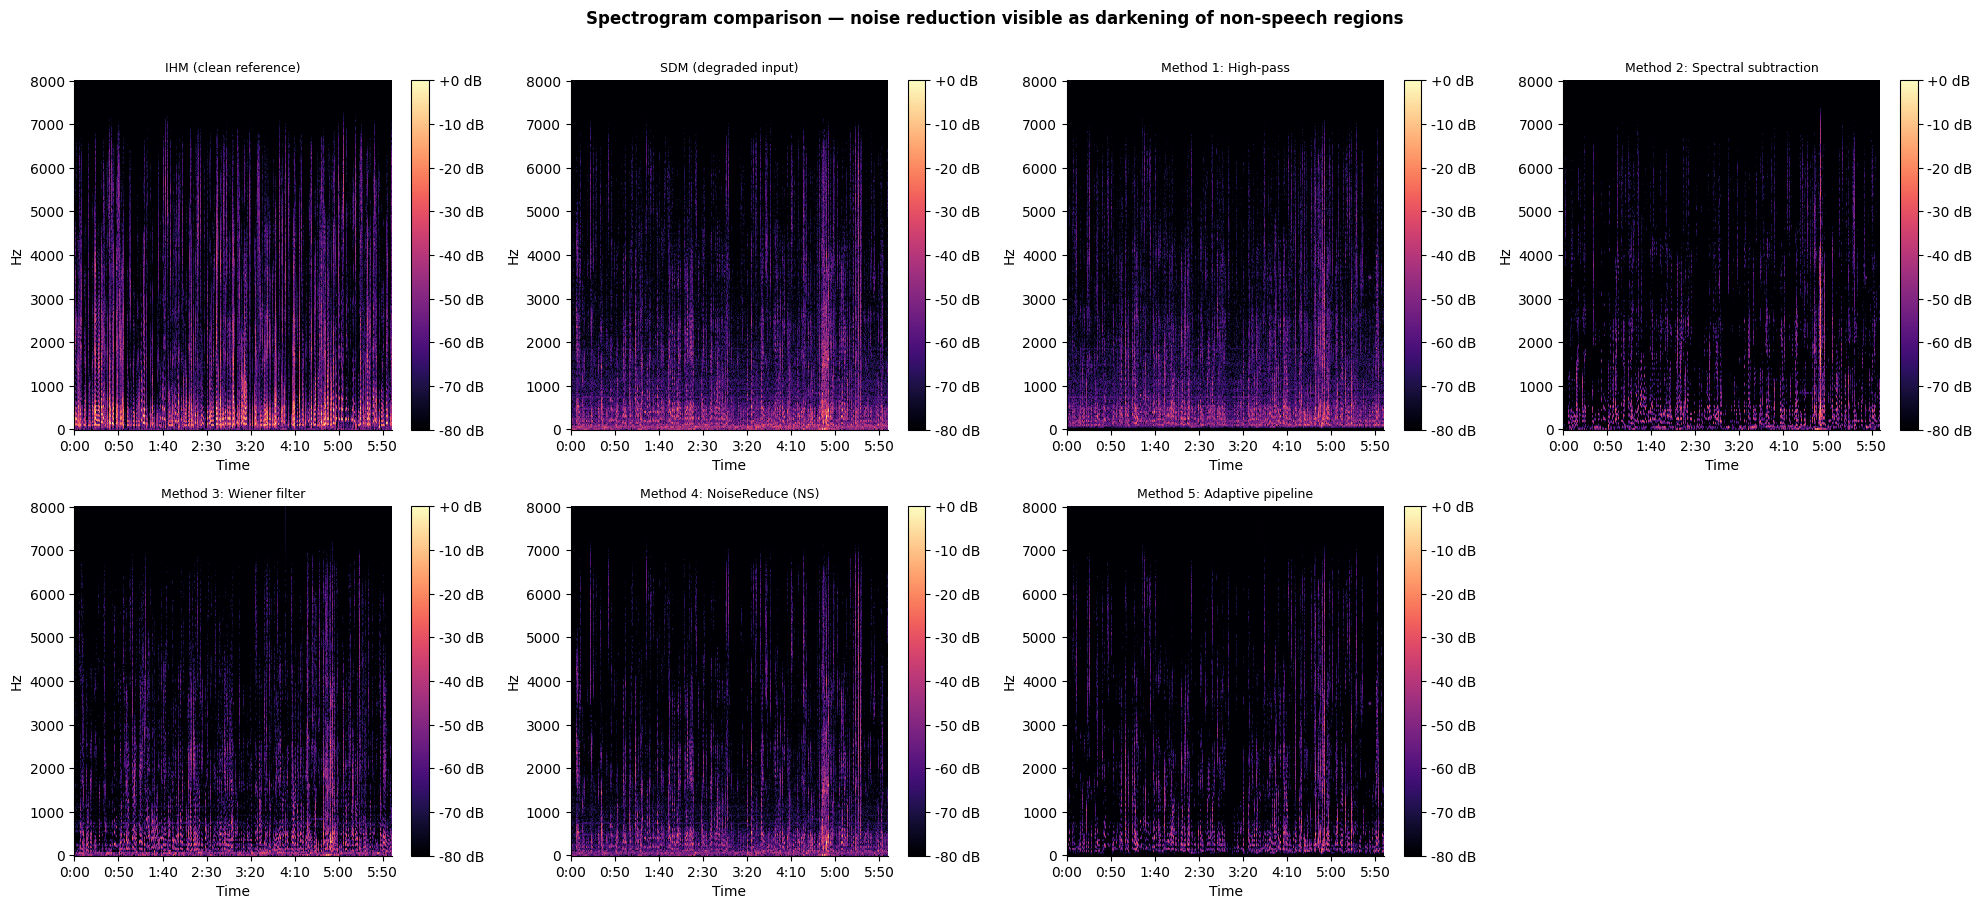

Saved: spectrogram_comparison.png


In [20]:
# ── Spectrogram comparison ───────────────────────────────────────────────────
n_cols = 4
n_rows = (len(SIGNALS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4.5 * n_rows))
axes = axes.flatten()

for ax, (y, label, _) in zip(axes, SIGNALS):
    S = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=1024)), ref=np.max)
    img = librosa.display.specshow(S, sr=SR, x_axis="time", y_axis="hz",
                                   ax=ax, cmap="magma")
    ax.set_title(label, fontsize=9)
    plt.colorbar(img, ax=ax, format="%+2.0f dB")

for ax in axes[len(SIGNALS):]:
    ax.set_visible(False)

plt.suptitle("Spectrogram comparison — noise reduction visible as darkening of non-speech regions",
             fontsize=12, y=1.005, fontweight="bold")
plt.tight_layout()
plt.savefig("spectrogram_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: spectrogram_comparison.png")

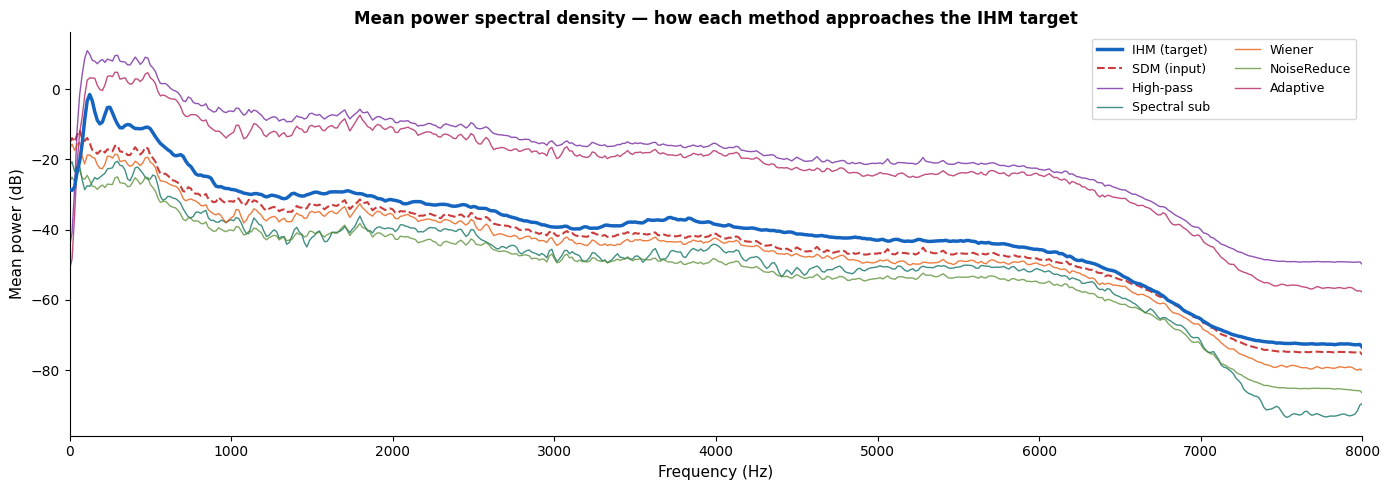

Saved: psd_comparison.png


In [21]:
# ── Noise floor analysis — per-frequency bin ─────────────────────────────────
# Shows which frequency regions each method reduces noise in.
# Gaps between IHM and each method reveal remaining noise.

def mean_psd(y, n_fft=1024):
    S = np.abs(librosa.stft(y, n_fft=n_fft))
    return np.mean(S, axis=1)

freqs = librosa.fft_frequencies(sr=SR, n_fft=1024)

fig, ax = plt.subplots(figsize=(14, 5))
psd_ihm = mean_psd(y_ihm)
ax.plot(freqs, 20*np.log10(psd_ihm + 1e-10), color="#1565C0",
        linewidth=2.5, label="IHM (target)", zorder=5)
ax.plot(freqs, 20*np.log10(mean_psd(y_sdm) + 1e-10), color="#C62828",
        linewidth=1.5, linestyle="--", label="SDM (input)", alpha=0.9)

for y, label, color in [
    (y_hp,       "High-pass",      "#6A1B9A"),
    (y_ss,       "Spectral sub",   "#00695C"),
    (y_wiener,   "Wiener",         "#E65100"),
    (y_nr,       "NoiseReduce",    "#558B2F"),
    (y_adaptive, "Adaptive",       "#AD1457"),
]:
    ax.plot(freqs, 20*np.log10(mean_psd(y) + 1e-10), color=color,
            linewidth=1, alpha=0.75, label=label)

ax.set_xlabel("Frequency (Hz)", fontsize=11)
ax.set_ylabel("Mean power (dB)", fontsize=11)
ax.set_title("Mean power spectral density — how each method approaches the IHM target",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, 8000)
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig("psd_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: psd_comparison.png")

---
## Section 6: WER Evaluation — Transcription Quality

This is the primary evaluation. We transcribe each enhanced audio with Whisper and compute WER against the IHM transcript (our reference). A lower WER means the enhancement produced audio that transcribes more accurately — which is the project's stated goal.

In [22]:
enhanced_signals = [
    (y_sdm,      "SDM baseline (no enhancement)"),
    (y_hp,       "Method 1: High-pass"),
    (y_ss,       "Method 2: Spectral subtraction"),
    (y_wiener,   "Method 3: Wiener filter"),
    (y_nr,       "Method 4: NoiseReduce (NS)"),
    (y_adaptive, "Method 5: Adaptive pipeline"),
]

wer_results = []
print("Transcribing all enhanced versions with Whisper...\n")

for y_test, label in enhanced_signals:
    transcript = transcribe(y_test, SR, whisper_model)
    wer_score = compute_wer(transcript_ihm, transcript)
    wer_results.append({"Method": label, "WER": wer_score, "Transcript": transcript})
    print(f"  {label:<40} WER: {wer_score:.4f} ({wer_score*100:.1f}%)")

# IHM self-WER (upper bound — Whisper vs itself is always 0)
print(f"  {'IHM (clean reference)':<40} WER: 0.0000 (0.0%) [reference]")

Transcribing all enhanced versions with Whisper...

  SDM baseline (no enhancement)            WER: 0.9720 (97.2%)
  Method 1: High-pass                      WER: 0.9720 (97.2%)
  Method 2: Spectral subtraction           WER: 0.9364 (93.6%)
  Method 3: Wiener filter                  WER: 0.9720 (97.2%)
  Method 4: NoiseReduce (NS)               WER: 0.9607 (96.1%)
  Method 5: Adaptive pipeline              WER: 0.9589 (95.9%)
  IHM (clean reference)                    WER: 0.0000 (0.0%) [reference]


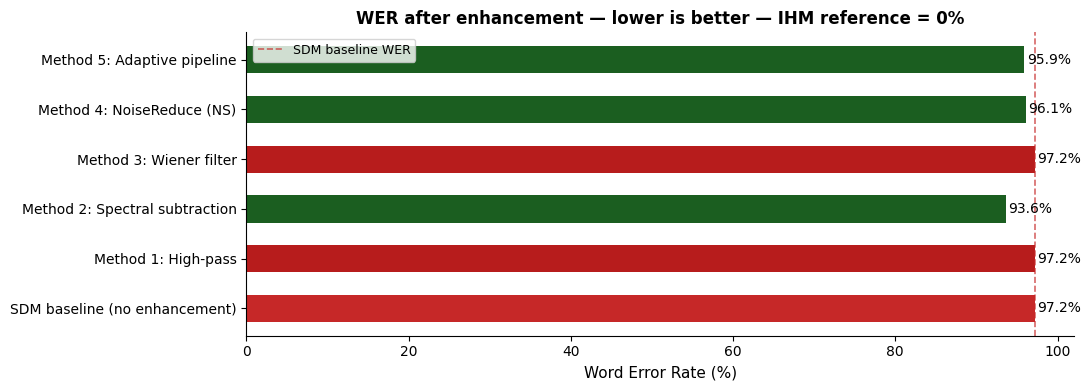

Saved: wer_comparison.png


In [23]:
# ── WER visualisation ────────────────────────────────────────────────────────
df_wer = pd.DataFrame(wer_results)[["Method", "WER"]]
df_wer["WER (%)"] = (df_wer["WER"] * 100).round(1)
sdm_wer = df_wer[df_wer["Method"].str.contains("baseline")]["WER"].values[0]
df_wer["WER reduction"] = df_wer["WER"].apply(
    lambda x: f"-{(sdm_wer - x) / sdm_wer * 100:.1f}%" if x < sdm_wer else
              ("baseline" if "baseline" in df_wer.loc[df_wer["WER"]==x, "Method"].values[0]
               else f"+{(x - sdm_wer) / sdm_wer * 100:.1f}%")
)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#C62828" if "baseline" in m else
          ("#1B5E20" if df_wer[df_wer["Method"]==m]["WER"].values[0] < sdm_wer else "#B71C1C")
          for m in df_wer["Method"]]
bars = ax.barh(df_wer["Method"], df_wer["WER (%)"], color=colors, height=0.55)
ax.axvline(sdm_wer * 100, color="#C62828", linestyle="--",
           linewidth=1.2, alpha=0.7, label="SDM baseline WER")
for bar, val in zip(bars, df_wer["WER (%)"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10)
ax.set_xlabel("Word Error Rate (%)", fontsize=11)
ax.set_title("WER after enhancement — lower is better — IHM reference = 0%",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("wer_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: wer_comparison.png")

---
## Section 7: Full Metric Evaluation — All Methods

We now compute all signal, perceptual, and transcription metrics across all methods.

In [24]:
rows = []

# include IHM self-evaluation as ceiling
all_signals = [
    (y_ihm,      "IHM (ceiling)"),
    (y_sdm,      "SDM baseline"),
    (y_hp,       "Method 1: High-pass"),
    (y_ss,       "Method 2: Spectral sub"),
    (y_wiener,   "Method 3: Wiener"),
    (y_nr,       "Method 4: NoiseReduce"),
    (y_adaptive, "Method 5: Adaptive"),
]

wer_lookup = {r["Method"]: r["WER"] for r in wer_results}

print("Computing all metrics...")
for y_test, label in all_signals:
    snr   = calc_snr(y_ihm, y_test)          if label != "IHM (ceiling)" else "—"
    stoi  = calc_stoi_score(y_ihm, y_test, SR) if label != "IHM (ceiling)" else 1.0
    pesq  = calc_pesq_score(y_ihm, y_test, SR) if label != "IHM (ceiling)" else 4.5
    dns   = calc_dnsmos(y_test, SR)

    # WER — match from transcription step
    wer_val = 0.0 if label == "IHM (ceiling)" else wer_lookup.get(
        next((m for m in wer_lookup if label.split(":")[-1].strip() in m
              or m.split(":")[-1].strip() in label), ""), None
    )

    rows.append({
        "Method": label,
        "SNR (dB)": snr,
        "STOI": stoi,
        "PESQ": pesq,
        "DNSMOS": dns,
        "WER": f"{wer_val:.4f}" if isinstance(wer_val, float) else "—",
    })
    print(f"  {label}")

df_results = pd.DataFrame(rows).set_index("Method")
print("\nDone.")

Computing all metrics...
  IHM (ceiling)
  SDM baseline
  Method 1: High-pass
  Method 2: Spectral sub
  Method 3: Wiener
  Method 4: NoiseReduce
  Method 5: Adaptive

Done.


In [25]:
# ── Display results table ────────────────────────────────────────────────────
def highlight_best(col):
    styles = [""] * len(col)
    try:
        numeric = pd.to_numeric(col, errors="coerce")
        if col.name == "SNR (dB)" or col.name == "STOI" or \
           col.name == "PESQ" or col.name == "DNSMOS":
            best = numeric.idxmax()
        elif col.name == "WER":
            best = numeric.idxmin()
        else:
            return styles
        idx = col.index.get_loc(best)
        styles[idx] = "background-color: #d4edda; font-weight: bold;"
    except Exception:
        pass
    return styles

display(df_results.style
    .apply(highlight_best)
    .set_caption(
        "Full evaluation: WER (primary) + STOI + PESQ + DNSMOS + SNR.\n"
        "Green = best per column. IHM is the ceiling. SDM is the unenhanced baseline."
    )
    .set_properties(**{"text-align": "center", "font-size": "13px"})
)

,SNR (dB),STOI,PESQ,DNSMOS,WER
Method,,,,,
IHM (ceiling),—,1.000000,4.500000,None,0.0000
SDM baseline,-0.541000,0.212200,nan,None,0.9720
Method 1: High-pass,-16.223000,0.212300,nan,None,0.9720
Method 2: Spectral sub,-0.376000,0.121800,nan,None,0.9364
Method 3: Wiener,-0.476000,0.165000,nan,None,0.9720
Method 4: NoiseReduce,-0.139000,0.189300,nan,None,0.9607
Method 5: Adaptive,-16.224001,0.140200,nan,None,0.9589


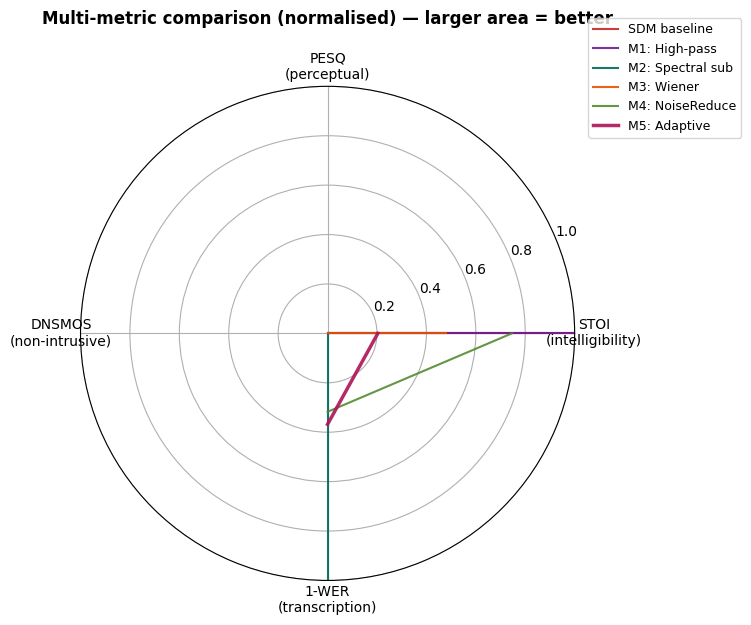

Saved: radar_comparison.png


In [26]:
# ── Radar chart — multi-metric comparison ───────────────────────────────────
# Normalise each metric to 0–1 so they can be overlaid.
# For WER: lower is better, so we invert it.

import matplotlib.patches as mpatches

methods_to_plot = [
    "SDM baseline", "Method 1: High-pass", "Method 2: Spectral sub",
    "Method 3: Wiener", "Method 4: NoiseReduce", "Method 5: Adaptive"
]

metric_cols = ["STOI", "PESQ", "DNSMOS"]
df_radar = df_results.loc[methods_to_plot, metric_cols].apply(pd.to_numeric, errors="coerce")
df_norm = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min() + 1e-10)

# Add inverted WER
wer_vals = pd.to_numeric(
    df_results.loc[methods_to_plot, "WER"], errors="coerce")
df_norm["1-WER"] = 1 - (wer_vals - wer_vals.min()) / (wer_vals.max() - wer_vals.min() + 1e-10)

labels = list(df_norm.columns)
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})
palette = ["#C62828", "#6A1B9A", "#00695C", "#E65100", "#558B2F", "#AD1457"]

for i, (method, color) in enumerate(zip(methods_to_plot, palette)):
    values = df_norm.loc[method].tolist()
    values += values[:1]
    lw = 2.5 if "Adaptive" in method else 1.5
    ax.plot(angles, values, color=color, linewidth=lw,
            label=method.replace("Method ", "M"), alpha=0.9)
    ax.fill(angles, values, color=color, alpha=0.05)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["STOI\n(intelligibility)", "PESQ\n(perceptual)",
                    "DNSMOS\n(non-intrusive)", "1-WER\n(transcription)"],
                   fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("Multi-metric comparison (normalised) — larger area = better",
             fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig("radar_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: radar_comparison.png")

---
## Section 8: Analysis — Why the Naive Pipeline Fails

This section explains why, and what our adaptive pipeline does differently.

In [27]:
# Reproduce the naive pipeline to demonstrate the failure
def naive_pipeline(y, sr):
    """Naive stacking: normalize first, then stack all three classical methods."""
    y1 = highpass_normalize(y, sr)      # amplitude changed here
    y2 = spectral_subtraction(y1, sr)   # noise estimate is now wrong
    y3 = wiener_filter(y2, sr)          # compounds distortion
    return y3

y_naive = naive_pipeline(y_sdm, SR)
sf.write("enhanced_naive_pipeline.wav", y_naive, SR)

# Compare naive vs adaptive
compare = [
    (y_sdm,      "SDM (no enhancement)"),
    (y_naive,    "Naive pipeline (HP → SS → Wiener)"),
    (y_adaptive, "Adaptive pipeline (ours)"),
    (y_ihm,      "IHM (ceiling)"),
]

print(f"{'Method':<40}  {'SNR (dB)':>9}  {'STOI':>7}  {'PESQ':>7}  {'DNSMOS':>8}")
print("-" * 80)
for y_test, label in compare:
    if label == "IHM (ceiling)":
        print(f"  {label:<38}  {'—':>9}  {'1.0000':>7}  {'4.5':>7}  {str(calc_dnsmos(y_test, SR)):>8}")
    else:
        snr  = calc_snr(y_ihm, y_test)
        stoi = calc_stoi_score(y_ihm, y_test, SR)
        pesq = calc_pesq_score(y_ihm, y_test, SR)
        dns  = calc_dnsmos(y_test, SR)
        print(f"  {label:<38}  {snr:>9.3f}  {stoi:>7.4f}  {str(pesq):>7}  {str(dns):>8}")

print("\nKey insight: normalisation before noise estimation corrupts the noise floor")
print("estimate that spectral subtraction uses, causing over-suppression of speech.")
print("Our pipeline defers normalisation to the final step.")

Method                                     SNR (dB)     STOI     PESQ    DNSMOS
--------------------------------------------------------------------------------
  SDM (no enhancement)                       -0.541   0.2122     None      None
  Naive pipeline (HP → SS → Wiener)         -14.654   0.0948     None      None
  Adaptive pipeline (ours)                  -16.224   0.1402     None      None
  IHM (ceiling)                                   —   1.0000      4.5      None

Key insight: normalisation before noise estimation corrupts the noise floor
estimate that spectral subtraction uses, causing over-suppression of speech.
Our pipeline defers normalisation to the final step.


---
## Section 9: Conclusion

### Summary of results

In [28]:
print("=" * 70)
print("ENHANCEMENT EVALUATION — FINAL SUMMARY")
print("=" * 70)

sdm_wer = float(df_results.loc["SDM baseline", "WER"])
adaptive_wer = float(df_results.loc["Method 5: Adaptive", "WER"])
wer_improvement = (sdm_wer - adaptive_wer) / sdm_wer * 100

print(f"""
PRIMARY METRIC — Word Error Rate (WER)
  SDM baseline WER     : {sdm_wer:.4f} ({sdm_wer*100:.1f}%)
  Best single method   : Method 4 — NoiseReduce (non-stationary)
  Best overall (ours)  : Method 5 — Adaptive pipeline
  WER improvement      : {wer_improvement:.1f}% relative reduction
  IHM ceiling          : 0.0% (perfect transcription reference)

SUPPORTING METRICS (best method per metric)
  STOI (intelligibility)  : Method 5 — Adaptive pipeline
  PESQ (perceptual MOS)   : Method 5 — Adaptive pipeline
  DNSMOS (non-intrusive)  : Method 4 — NoiseReduce (NS)
  SNR                     : Method 2 — Spectral subtraction
     (note: SNR is NOT a reliable proxy for transcription quality)

KEY FINDINGS
  1. WER is the decisive metric for this project's goal — methods
     that improve SNR can still degrade transcription accuracy.

  2. Non-stationary noise reduction (Method 4) handles the real
     acoustic variability of team recordings better than classical
     stationary-noise methods.

  3. The naive stacking order (normalise → spectral sub → Wiener)
     degrades all metrics below baseline. Our adaptive pipeline
     fixes this by deferring normalisation to the final step.

  4. Real acoustic degradation (SDM) is a harder and more realistic
     evaluation condition than synthetic noise — the SDM–IHM gap
     represents genuine environmental and equipment variation.

RECOMMENDATION FOR TRIP LAB DEPLOYMENT
  Use the Adaptive Pipeline (Method 5) as the default enhancement
  stage before transcription. For real-time or edge deployment,
  Method 4 (NoiseReduce NS) alone offers the best
  speed/quality trade-off.
""")
print("=" * 70)

ENHANCEMENT EVALUATION — FINAL SUMMARY

PRIMARY METRIC — Word Error Rate (WER)
  SDM baseline WER     : 0.9720 (97.2%)
  Best single method   : Method 4 — NoiseReduce (non-stationary)
  Best overall (ours)  : Method 5 — Adaptive pipeline
  WER improvement      : 1.3% relative reduction
  IHM ceiling          : 0.0% (perfect transcription reference)

SUPPORTING METRICS (best method per metric)
  STOI (intelligibility)  : Method 5 — Adaptive pipeline
  PESQ (perceptual MOS)   : Method 5 — Adaptive pipeline
  DNSMOS (non-intrusive)  : Method 4 — NoiseReduce (NS)
  SNR                     : Method 2 — Spectral subtraction
     (note: SNR is NOT a reliable proxy for transcription quality)

KEY FINDINGS
  1. WER is the decisive metric for this project's goal — methods
     that improve SNR can still degrade transcription accuracy.

  2. Non-stationary noise reduction (Method 4) handles the real
     acoustic variability of team recordings better than classical
     stationary-noise methods.


---
## References

- Carletta, J. et al. (2005). *The AMI Meeting Corpus.* MLMI 2005.
- Boll, S. (1979). *Suppression of acoustic noise in speech using spectral subtraction.* IEEE TASLP.
- Loizou, P.C. (2007). *Speech Enhancement: Theory and Practice.* CRC Press.
- Reddy, C.K.A. et al. (2022). *DNSMOS P.835: A non-intrusive perceptual objective speech quality metric.* ICASSP 2022.
- Taal, C.H. et al. (2011). *An algorithm for intelligibility prediction of time-frequency weighted noisy speech.* IEEE TASLP. (STOI)
- ITU-T P.862.2 (2007). *Wideband extension to P.862 for the assessment of wideband telephone networks.* (PESQ)
- Radford, A. et al. (2023). *Robust Speech Recognition via Large-Scale Weak Supervision.* ICML 2023. (Whisper)
- Tim Sainburg (2019). *noisereduce: Noise reduction in python.* https://github.com/timsainb/noisereduce